In [2]:
import pandas as pd
from PIL import Image

import torch
from torch.utils.data import Dataset
from torchvision import transforms
from pathlib import Path
from typing import Any

In [3]:
DATA_DIR = Path('../data/')
MAN_DIR = DATA_DIR / 'manifests'
RAW_DIR = DATA_DIR / 'raw'
XLSX_PATH = RAW_DIR / 'pat_info.xlsx'
PAR_PATH = MAN_DIR / 'image_manifest_images_only.parquet'

In [4]:
basic_transform = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.ToTensor(),
    transforms.Normalize(
        mean=[0.485, 0.456, 0.406],
        std=[0.229, 0.224, 0.225]
    )
])

In [5]:
VALID_SPLITS = {"train", "val", "test"}

In [17]:
class MEEIDataset(Dataset):
    def __init__(self, manifest_path: Path, split: str, transform=None):
        self.manifest_path = Path(manifest_path)
        self.split = split
        self.transform = transform if transform is not None else basic_transform

        df = pd.read_parquet(self.manifest_path)
        self.samples = self._build_patient_samples(df=df, split=split)

    def __len__(self):
        return len(self.samples)

    def __getitem__(self, idx):
        sample = self.samples[idx]

        images = []
        for filepath in sample["filepaths"]:
            image = Image.open(filepath).convert("RGB")

            if self.transform is not None:
                image = self.transform(image)

            images.append(image)

        # Stack into [num_poses, C, H, W]
        images = torch.stack(images, dim=0)

        # Label as tensor
        label = torch.tensor(sample["hb_grade"], dtype=torch.long)

        return {
            "images": images,
            "label": label,
            "patient_id": sample["patient_id"],
            "pose_indices": sample["pose_indices"]
        }

    @staticmethod
    def _build_patient_samples(df: pd.DataFrame, split: str) -> list[dict[str, Any]]:
        """Build one sample per patient from a split-filtered manifest."""
        if split not in VALID_SPLITS:
            raise ValueError(f"Invalid split '{split}'. Expected one of {sorted(VALID_SPLITS)}")
    
        required_cols = {"patient_id", "pose_index", "filepath", "hb_grade", "split"}
        missing = required_cols - set(df.columns)
        if missing:
            raise ValueError(f"Manifest missing required columns: {sorted(missing)}")
    
        split_df = df[df["split"] == split].copy()
        if split_df.empty:
            raise ValueError(f"No rows found for split '{split}'.")
    
        split_df = split_df.sort_values(["patient_id", "pose_index"]).reset_index(drop=True)
        samples: list[dict[str, Any]] = []
    
        for patient_id, group in split_df.groupby("patient_id"):
            group = group.sort_values("pose_index")
    
            filepaths = group["filepath"].tolist()
            pose_indices = group["pose_index"].tolist()
    
            labels = group["hb_grade"].unique()
            if len(labels) != 1:
                raise ValueError(
                    f"Patient {patient_id} has multiple hb_grade values: {labels}"
                )
            if not filepaths:
                raise ValueError(f"Patient {patient_id} has no image rows in split '{split}'.")
    
            samples.append({
                "patient_id": patient_id,
                "filepaths": filepaths,
                "pose_indices": pose_indices,
                "hb_grade": int(labels[0])
            })
    
        return samples

In [18]:
test_obj = MEEIDataset(PAR_PATH, "train", basic_transform)
print("Dataset length:", len(test_obj))
print("Sample keys:", test_obj[0].keys())
print("Sample image tensor shape:", test_obj[0]["images"].shape)
print("Sample label:", test_obj[0]["label"])
print("Sample patient ID:", test_obj[0]["patient_id"])
print("Sample pose indices:", test_obj[0]["pose_indices"])

Dataset length: 42
Sample keys: dict_keys(['images', 'label', 'patient_id', 'pose_indices'])
Sample image tensor shape: torch.Size([8, 3, 224, 224])
Sample label: tensor(6)
Sample patient ID: CompleteFlaccid2
Sample pose indices: [1.0, 2.0, 3.0, 4.0, 5.0, 6.0, 7.0, 8.0]


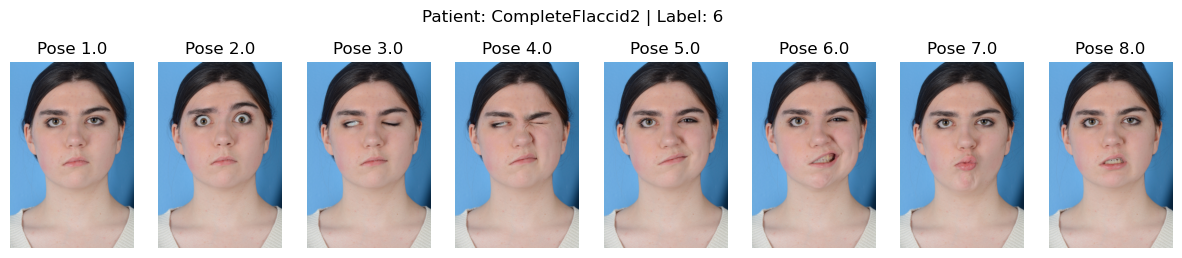

In [19]:
import matplotlib.pyplot as plt
from PIL import Image

sample = test_obj.samples[0]
num_poses = len(sample["filepaths"])

plt.figure(figsize=(15, 3))

for i, img_path in enumerate(sample["filepaths"]):
    img = Image.open(img_path).convert("RGB")

    plt.subplot(1, num_poses, i + 1)
    plt.imshow(img)
    plt.title(f"Pose {sample['pose_indices'][i]}")
    plt.axis("off")

plt.suptitle(f"Patient: {sample['patient_id']} | Label: {sample['hb_grade']}")
plt.show()